In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Load the dataset directly from a URL
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

print("--- First 5 Rows ---")
print(df.head())

print("--- Basic Info ---")
# .info() is a great first command. It tells us the column names, how many non-null values are in each column, and their data types.
# Notice that 'Age' and 'Cabin' have missing values!
df.info()

### Inspecting the code checking for missing values and data types

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## We are looking fr statistical description of the data
#### The average age of passengers
#### Survival rate 
#### How much the fare cost

In [3]:
# Get summary statistics for numerical columns
print("--- Descriptive Statistics ---")
print(df.describe())

print("--- Key Insights from Statistics ---")
print(f"The average age of a passenger was {df['Age'].mean():.1f} years.")
print(f"The overall survival rate was {df['Survived'].mean():.1%}.")
print(f"Fares ranged from ${df['Fare'].min()} to a whopping ${df['Fare'].max()}.")

--- Descriptive Statistics ---
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
--- Key Insights from Statistics ---
The average a

### The actual visualization of the data for those who survived and those who died.


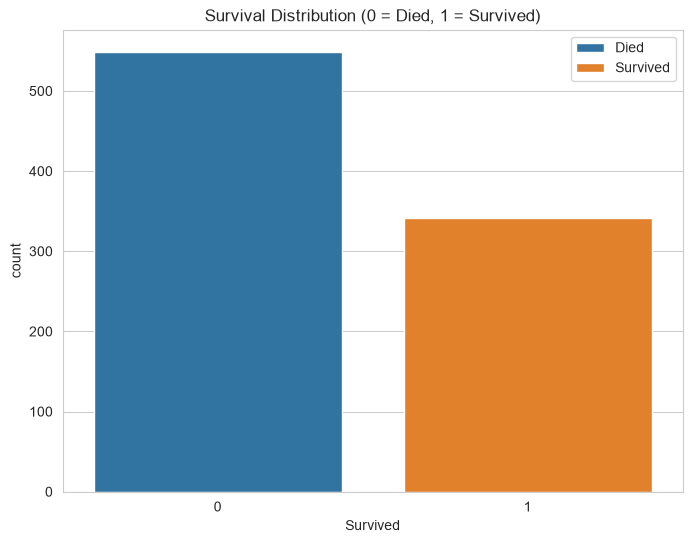

Insight: Far more people died than survived. This is an example of an imbalanced dataset, which can sometimes be a challenge for machine learning models.


In [15]:
import seaborn as sns

sns.set_style('whitegrid') # Sets a nice visual style for our plots
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived',hue='Survived', data=df)
plt.title('Survival Distribution (0 = Died, 1 = Survived)')
plt.legend(['Died', 'Survived'])
plt.show()

print("Insight: Far more people died than survived. This is an example of an imbalanced dataset, which can sometimes be a challenge for machine learning models.")

### Here the actual representation of who survived among the three classes of the ship.

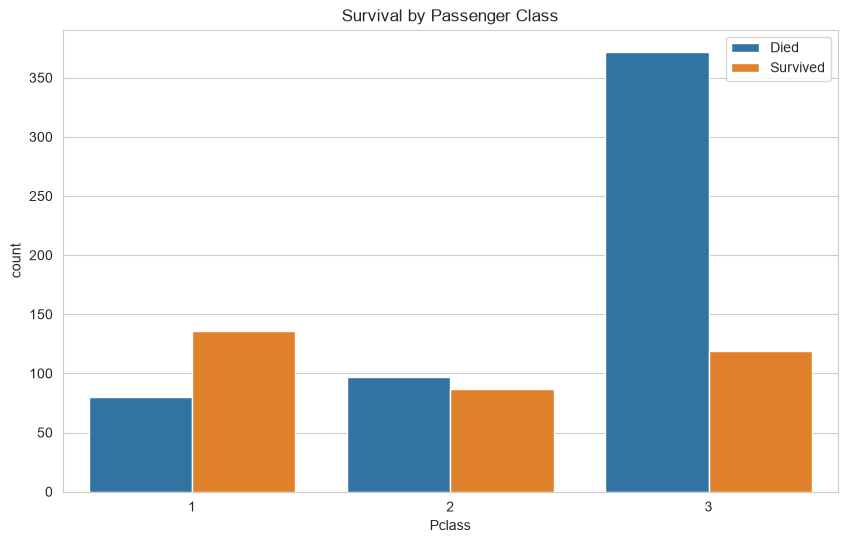

Insight: This is a very strong pattern. 1st class passengers had a much higher chance of survival compared to 3rd class passengers. Money seems to have made a difference.


In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.legend(['Died', 'Survived'])
plt.show()

print("Insight: This is a very strong pattern. 1st class passengers had a much higher chance of survival compared to 3rd class passengers. Money seems to have made a difference.")

### Checking data by gender. Which gender survived 
##### There was enough room on the raft 

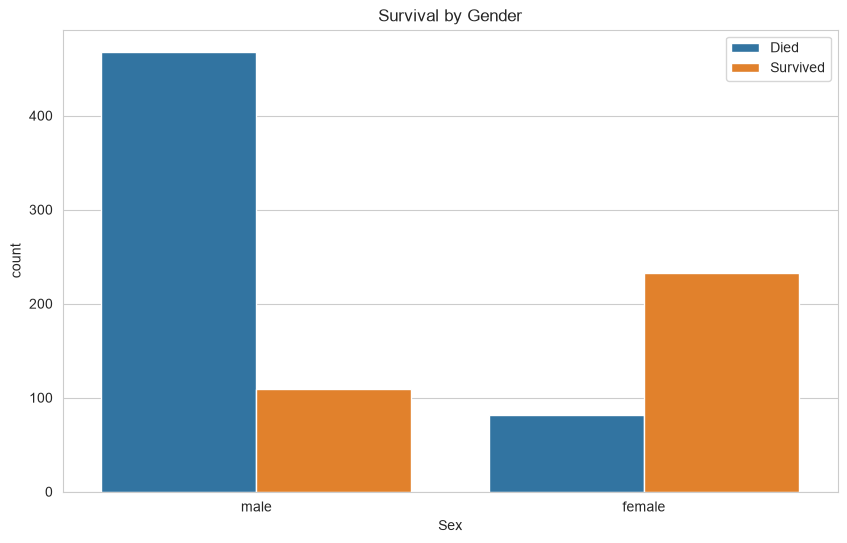

Insight: The pattern is undeniable. A much higher proportion of females survived compared to males. This is another very strong predictor.


In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.legend(['Died', 'Survived'])
plt.show()

print("Insight: The pattern is undeniable. A much higher proportion of females survived compared to males. This is another very strong predictor.")

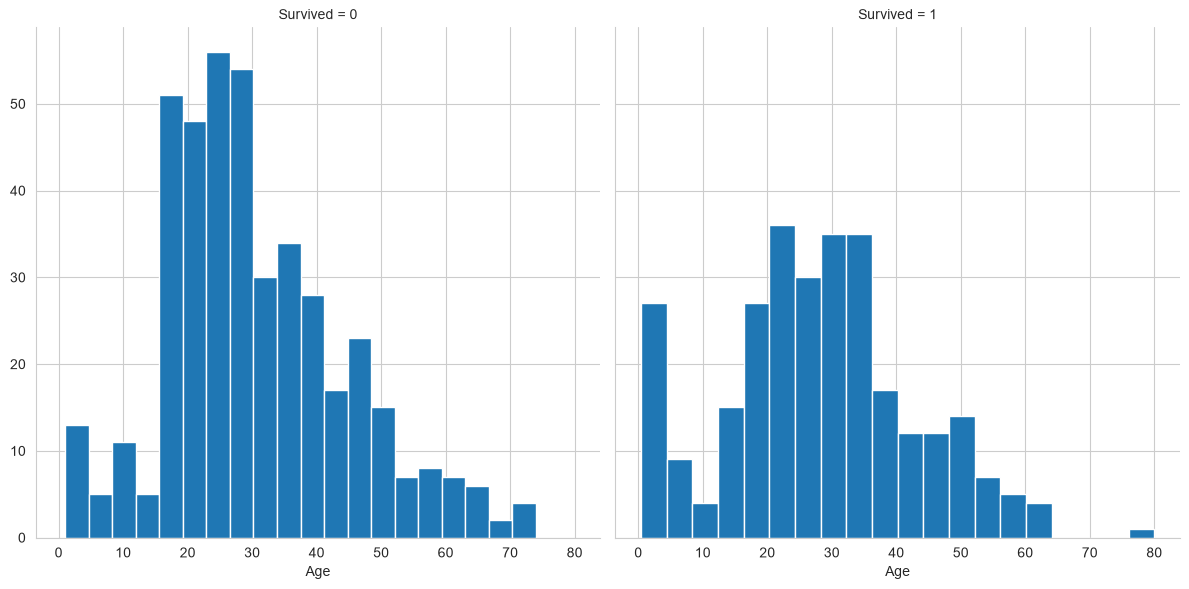

Insight: The age distribution for those who did not survive is centered around the 20-40 age range. For those who survived, there is a noticeable spike for young children. This supports the 'children' part of the mantra.


In [7]:
# A FacetGrid allows us to create multiple plots side-by-side to compare distributions.
# Here, we create one histogram for passengers who died (col='Survived'=0) and one for those who survived (col='Survived'=1).
g = sns.FacetGrid(df, col='Survived', height=6)
g.map(plt.hist, 'Age', bins=20)
plt.show()

print("Insight: The age distribution for those who did not survive is centered around the 20-40 age range. For those who survived, there is a noticeable spike for young children. This supports the 'children' part of the mantra.")

## Embarked
### We are checking to see how many passengers point of entry to the Titanic. 
### Southampton had the highest number of the three but also highest number of deaths.

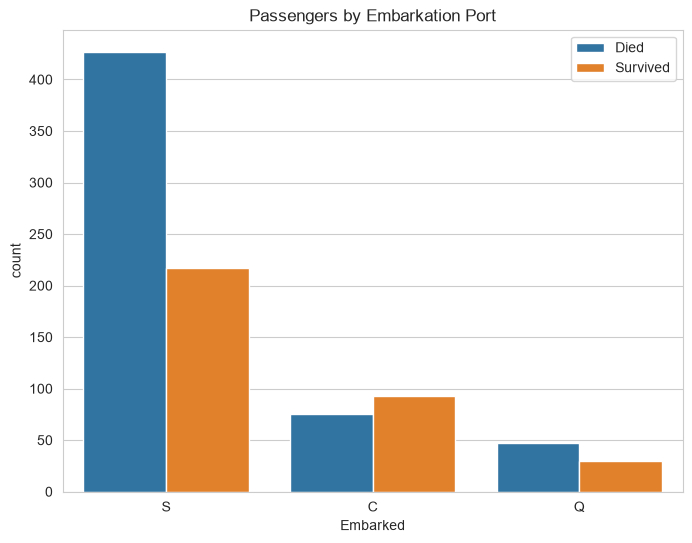

Insight: Most passengers embarked from Southampton (S), followed by Cherbourg (C) and Queenstown (Q). This could be relevant for understanding the distribution of passengers and potential biases in the dataset.


In [10]:
df['Embarked'].value_counts()

plt.figure(figsize=(8, 6))
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title('Passengers by Embarkation Port')
plt.legend(['Died', 'Survived'])
plt.show()
print("Insight: Most passengers embarked from Southampton (S), followed by Cherbourg (C) and Queenstown (Q). This could be relevant for understanding the distribution of passengers and potential biases in the dataset.")

### Fare prices
#### correlation between price of the fare and survival of passengers


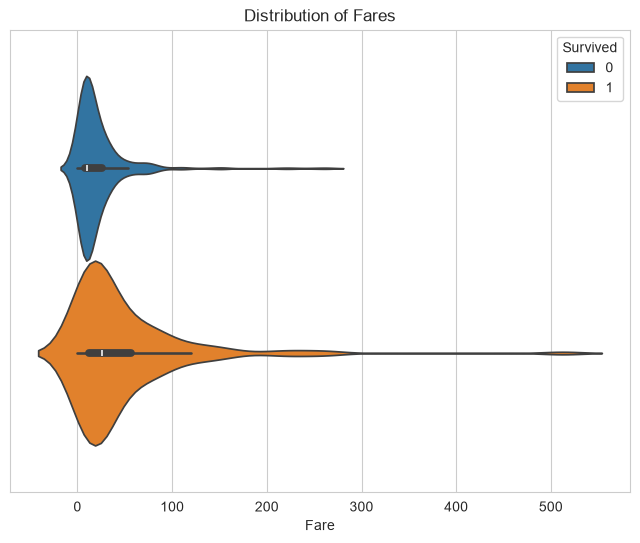

Insight: The distribution of fares is right-skewed, with most passengers paying lower fares and a few paying very high fares.


In [13]:
df["Fare"].value_counts()

plt.figure(figsize=(8, 6))
sns.violinplot(x='Fare', hue='Survived', data=df)
plt.title('Distribution of Fares')
plt.show()

print("Insight: The distribution of fares is right-skewed, with most passengers paying lower fares and a few paying very high fares.")